In [1]:
import pandas as pd
import numpy as np
import nrrd
import matplotlib.pyplot as plt
import os

from pathlib import Path

current = Path().resolve()

while not (current / ".git").exists():
    current = current.parent

PROJECT_ROOT = current

output_folder = PROJECT_ROOT / "extension/"

# Olfactory bulb

For olfactory / paleocortex (3-layer cortex) PIR, AON, COAa, COApl, COApm, NLOT1–3

The core regions that matter for olfactory paleocortex

🔴 Absolutely central (primary paleocortex)

PIR — Piriform cortex
→ canonical 3-layer paleocortex

AON — Anterior olfactory nucleus
→ transitional paleocortex

🟠 Accessory olfactory / cortical amygdala (still paleocortical)

These follow the same 3-layer logic, though sometimes distorted.

COAa — Cortical amygdala, anterior

COApl — Cortical amygdala, posterolateral

COApm — Cortical amygdala, posteromedial

NLOT1 / NLOT2 / NLOT3 — Nucleus of the lateral olfactory tract

AAA — Anterior amygdalar area

MEA — Medial amygdala (olfactory-driven subdivisions)

These are often grouped as olfactory amygdala / paleocortex-like cortex.

🟡 Olfactory bulb (not cortex, but essential for context)

Not layered like cortex, but upstream and often included in olfactory datasets.

MOB sublayers:

MOBglomerularlayer

MOBopl

MOBipl

MOBgr

MOBmi

AOBgl / AOBmi / AOBgr — Accessory olfactory bulb

🟢 Border / transitional cortices (optional)

These are not classic paleocortex, but often included when people study olfactory–hippocampal or olfactory–association transitions.

ENTl1–3, ENTm1–3 — superficial entorhinal layers

ECT1 / ECT23 — ectorhinal cortex

PERI1 / PERI23 — perirhinal cortex

APr — anterior parietal area (border region)

In [3]:
file = output_folder / 'data/brain_regions_me_types_composition.csv'
me_data_df = pd.read_csv(file, index_col=0, header=[0, 1])

# Combine the two levels of the MultiIndex into one
me_data_df.columns = [f"{col[0]}|{col[1]}" for col in me_data_df.columns]

me_data_df.shape

(691, 458)

In [4]:
me_data_df.T[['PIR', 'AON', 'COAa', 'COApl', 'COApm', 'NLOT1', 'NLOT2', 'NLOT3']]

,PIR,AON,COAa,COApl,COApm,NLOT1,NLOT2,NLOT3
IN_DEND_0_AX_0|bAC,3.613544,8.135984,7.382547,4.085830,7.026847,2.026182,2.916758,11.897982
IN_DEND_0_AX_3|bAC,487.062171,452.929628,290.529509,305.020400,294.053328,38.668163,291.962559,443.534823
IN_DEND_0_AX_4|bAC,280.645592,756.651094,436.735831,739.776978,686.654252,39.915954,78.373959,223.934613
IN_DEND_0_AX_5|bAC,60.921667,116.601509,71.809460,78.045543,79.603252,14.149296,15.786395,82.271534
IN_DEND_0_AX_6|bAC,36.844668,46.137899,30.749455,46.252444,38.205268,10.757896,5.553800,65.545889
...,...,...,...,...,...,...,...,...
IN_DEND_8_AX_8|dSTUT,40.119228,80.467051,33.234739,70.335678,58.848173,2.541838,4.856026,17.288318
IN_DEND_9_AX_1|dSTUT,12.899515,8.557084,20.789778,13.637820,15.385313,4.060367,2.431649,10.602277
IN_DEND_9_AX_2|dSTUT,1.166887,6.854607,0.445207,0.855393,1.418482,0.095088,0.000000,0.789983
IN_DEND_9_AX_5|dSTUT,1.384961,3.202652,1.438514,0.850308,0.690678,0.779029,1.625789,2.670516


### Summary: None of these regions can be split into their layers superficial (Layer I–like), intermediate (Layer II–like), deep (Layer III–like) zones therefor we can't show laminarity in the OLF


# CORTEX

VISp1, VISp4, VISp5, VISp6a, VISp6b

SSs1, SSs23, SSs4, SSs5, SSs6a, SSs6b

AUDd1, AUDd4, AUDd5, AUDd6a, AUDd6b

MOp1, MOp23, MOp5, MOp6a, MOp6b

ACAd1, ACAd23, ACAd5, ACAd6a, ACAd6b

ORBl1, ORBl23, ORBl5, ORBl6a, ORBl6b

ILA1, ILA23, ILA5, ILA6a, ILA6b

PL1, PL23, PL5, PL6a, PL6b

## EPHYS types

Abbreviation Meaning	Notes

cADpyr	continuous adapting pyramidal neuron, excitatory

bAC	bursting accommodating	inhibitory, 

bIR bursting irregular spiking	inhibitory

bNAC bursting non-adapting 	inhibitory

bSTUT bursting stuttering	inhibitory

cAC	continuous adapting	inhibitory

cIR	continuous irregular spiking inhibitory

cNAC continuous Non-Adapting inhibitory

cSTUT continuous stuttering inhibitory

dNAC delayed Non-accommodating neuron inhibitory

dSTUT delayed stuttering neuron inhibitory

In [6]:
file = output_folder / 'data/brain_regions_e_types_composition.csv'
e_data_df = pd.read_csv(file, index_col=0)

In [7]:
e_data_df.T[['VISp1', 'VISp23', 'VISp4', 'VISp5', 'VISp6a', 'VISp6b']]

,VISp1,VISp23,VISp4,VISp5,VISp6a,VISp6b
bAC,1644.983931,12241.199197,17098.927775,8887.296408,10581.615584,13663.785343
bIR,611.566277,4444.073348,6247.562743,3643.150784,4128.349595,5375.225724
bNAC,900.637882,6814.630531,9170.157800,5321.098817,5851.674890,7560.539454
bSTUT,58.643660,386.304604,480.953828,613.624997,507.444327,685.891621
cAC,749.040318,5318.720260,6144.413308,5583.966885,5278.232492,7018.252002
cADpyr,3481.911151,59262.570826,67354.822820,29969.753112,56820.138445,63710.326765
cIR,47.533049,276.831181,446.397454,567.738401,479.445447,652.651462
cNAC,181.786210,997.658721,1443.436170,1725.567803,1641.831546,2253.839195
cSTUT,66.155058,463.362855,539.448751,701.415476,554.697394,745.230232
dNAC,26.133408,263.589925,151.546219,221.467554,122.505013,151.917381


In [8]:
# Define neuron type groups
excitatory = ["cADpyr"]
inhibitory = ["cAC", "bAC","bIR","bNAC","bSTUT", "cIR","cNAC","cSTUT","dNAC","dSTUT"]

laminar_order = ["VISp1","VISp23","VISp4","VISp5","VISp6a","VISp6b"]
df = e_data_df.T[laminar_order]
df.sum()

VISp1       8017.336574
VISp23     92635.649731
VISp4     111576.902052
VISp5      58375.880933
VISp6a     87228.480500
VISp6b    103372.481554
dtype: float64

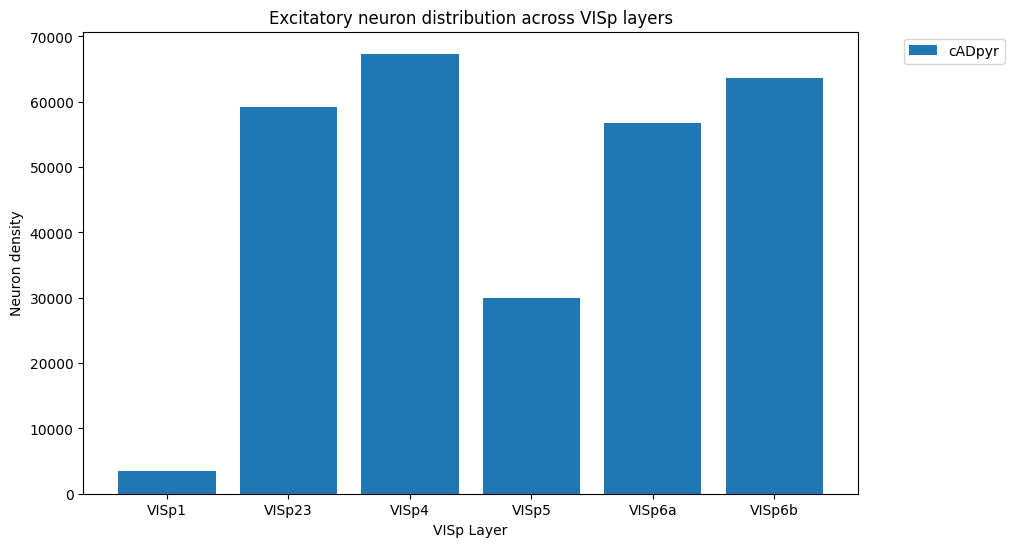

In [9]:
# Set up figure
plt.figure(figsize=(10,6))

# Plot excitatory neurons stacked
bottoms = [0]*len(laminar_order)
for neuron in excitatory:
    plt.bar(laminar_order, df.loc[neuron], bottom=bottoms, label=neuron)
    bottoms = [sum(x) for x in zip(bottoms, df.loc[neuron])]

plt.xlabel("VISp Layer")
plt.ylabel("Neuron density")
plt.title("Excitatory neuron distribution across VISp layers")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

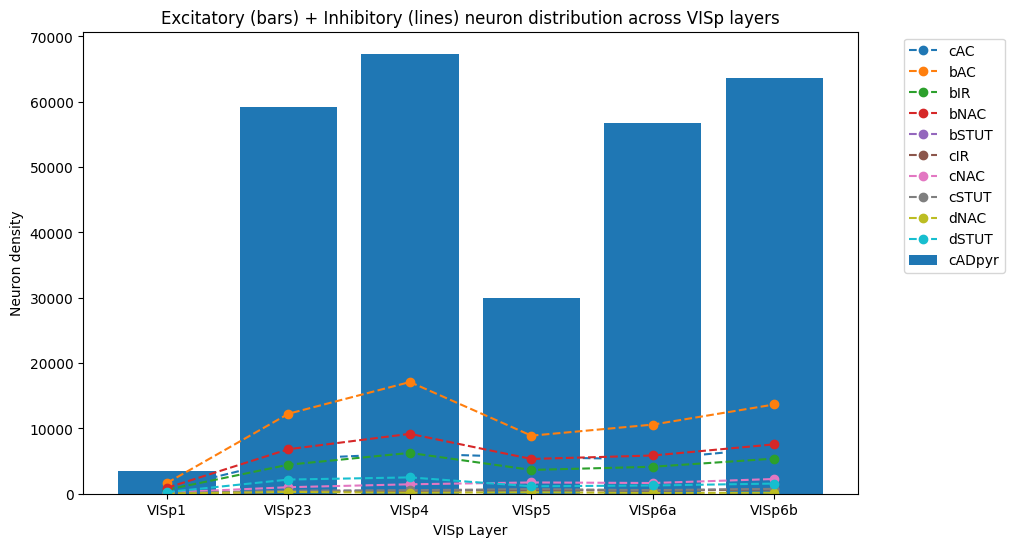

In [10]:
plt.figure(figsize=(10,6))

# Plot excitatory stacked bars first
bottoms = [0]*len(laminar_order)
for neuron in excitatory:
    plt.bar(laminar_order, df.loc[neuron], bottom=bottoms, label=neuron)
    bottoms = [sum(x) for x in zip(bottoms, df.loc[neuron])]

# Plot inhibitory neurons as line plots
for neuron in inhibitory:
    plt.plot(laminar_order, df.loc[neuron], marker='o', linestyle='--', label=neuron)

plt.xlabel("VISp Layer")
plt.ylabel("Neuron density")
plt.title("Excitatory (bars) + Inhibitory (lines) neuron distribution across VISp layers")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

In [11]:
[col for col in e_data_df.T.columns if col.startswith("SSs")]


['SSs1', 'SSs23', 'SSs4', 'SSs5', 'SSs6a', 'SSs6b']

In [12]:
laminar_order = ["SSs1", "SSs23", "SSs4", "SSs5", "SSs6a", "SSs6b"]
df = e_data_df.T[laminar_order]
df.sum()

SSs1      8949.646279
SSs23    80159.732507
SSs4     74507.182660
SSs5     34959.216184
SSs6a    66261.415550
SSs6b    72102.545676
dtype: float64

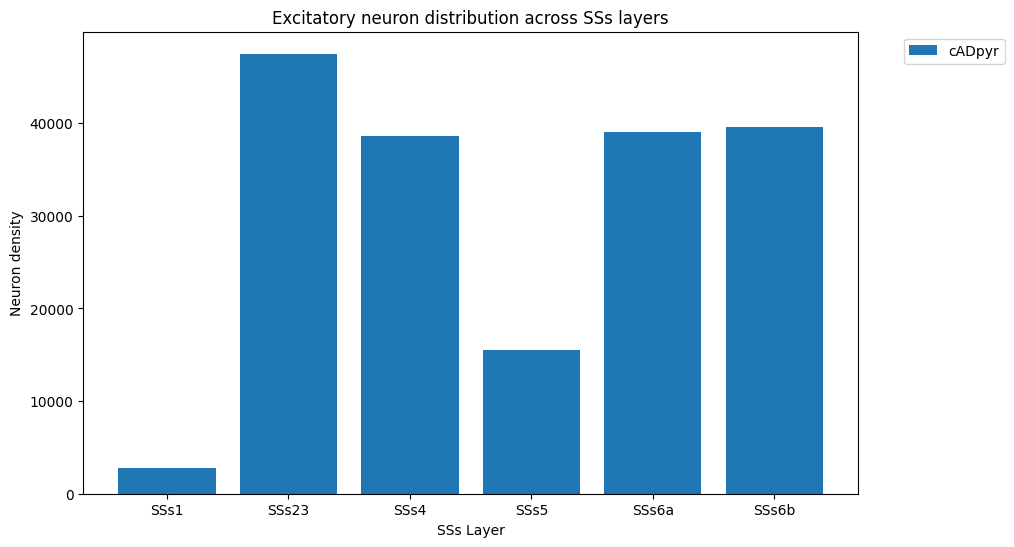

In [13]:
# Set up figure
plt.figure(figsize=(10,6))

# Plot excitatory neurons stacked
bottoms = [0]*len(laminar_order)
for neuron in excitatory:
    plt.bar(laminar_order, df.loc[neuron], bottom=bottoms, label=neuron)
    bottoms = [sum(x) for x in zip(bottoms, df.loc[neuron])]

plt.xlabel("SSs Layer")
plt.ylabel("Neuron density")
plt.title("Excitatory neuron distribution across SSs layers")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

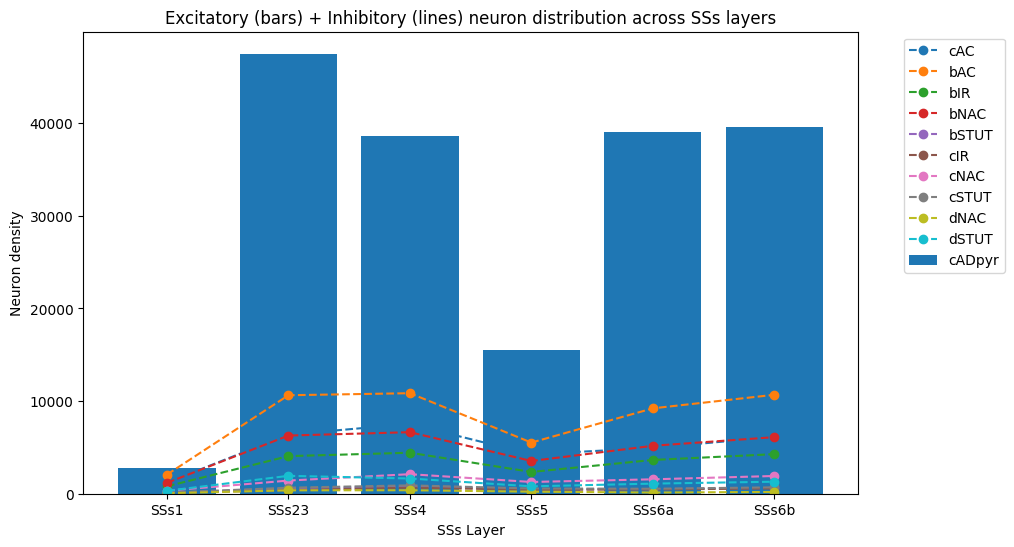

In [14]:
plt.figure(figsize=(10,6))

# Plot excitatory stacked bars first
bottoms = [0]*len(laminar_order)
for neuron in excitatory:
    plt.bar(laminar_order, df.loc[neuron], bottom=bottoms, label=neuron)
    bottoms = [sum(x) for x in zip(bottoms, df.loc[neuron])]

# Plot inhibitory neurons as line plots
for neuron in inhibitory:
    plt.plot(laminar_order, df.loc[neuron], marker='o', linestyle='--', label=neuron)

plt.xlabel("SSs Layer")
plt.ylabel("Neuron density")
plt.title("Excitatory (bars) + Inhibitory (lines) neuron distribution across SSs layers")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

In [15]:
[col for col in e_data_df.T.columns if col.startswith("AUD")]


['AUDd1',
 'AUDd23',
 'AUDd4',
 'AUDd5',
 'AUDd6a',
 'AUDd6b',
 'AUDp1',
 'AUDp23',
 'AUDp4',
 'AUDp5',
 'AUDp6a',
 'AUDp6b',
 'AUDpo1',
 'AUDpo23',
 'AUDpo4',
 'AUDpo5',
 'AUDpo6a',
 'AUDpo6b',
 'AUDv1',
 'AUDv23',
 'AUDv4',
 'AUDv5',
 'AUDv6a',
 'AUDv6b']

In [16]:
laminar_order = ["AUDv1", "AUDv23", "AUDv4", "AUDv5", "AUDv6a", "AUDv6b"]
df = e_data_df.T[laminar_order]
df.sum()

AUDv1      8681.493408
AUDv23    80594.156421
AUDv4     86169.957231
AUDv5     41517.240026
AUDv6a    74928.758701
AUDv6b    71863.735869
dtype: float64

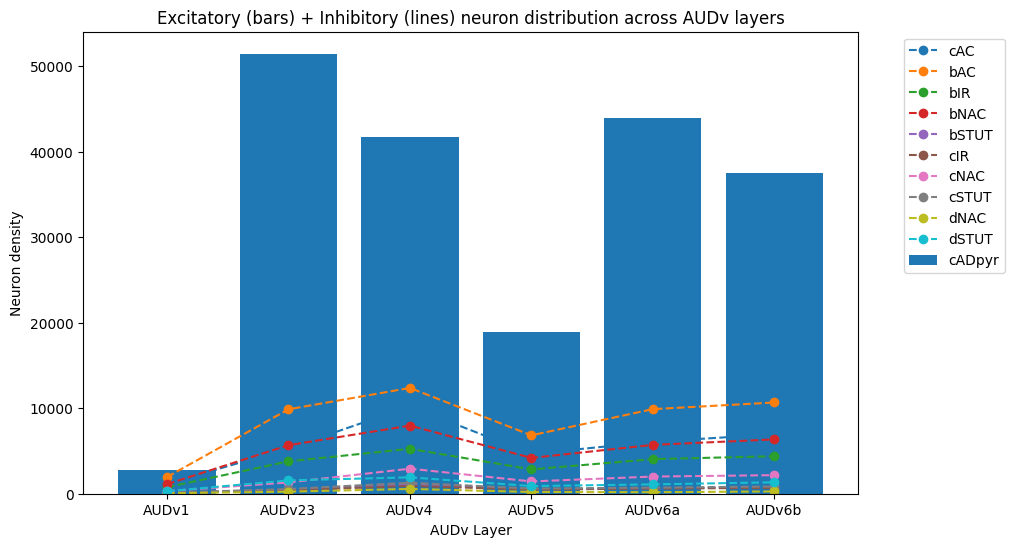

In [17]:
plt.figure(figsize=(10,6))

# Plot excitatory stacked bars first
bottoms = [0]*len(laminar_order)
for neuron in excitatory:
    plt.bar(laminar_order, df.loc[neuron], bottom=bottoms, label=neuron)
    bottoms = [sum(x) for x in zip(bottoms, df.loc[neuron])]

# Plot inhibitory neurons as line plots
for neuron in inhibitory:
    plt.plot(laminar_order, df.loc[neuron], marker='o', linestyle='--', label=neuron)

plt.xlabel("AUDv Layer")
plt.ylabel("Neuron density")
plt.title("Excitatory (bars) + Inhibitory (lines) neuron distribution across AUDv layers")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

In [18]:
[col for col in e_data_df.T.columns if col.startswith("ILA")]

['ILA1', 'ILA23', 'ILA5', 'ILA6a', 'ILA6b']

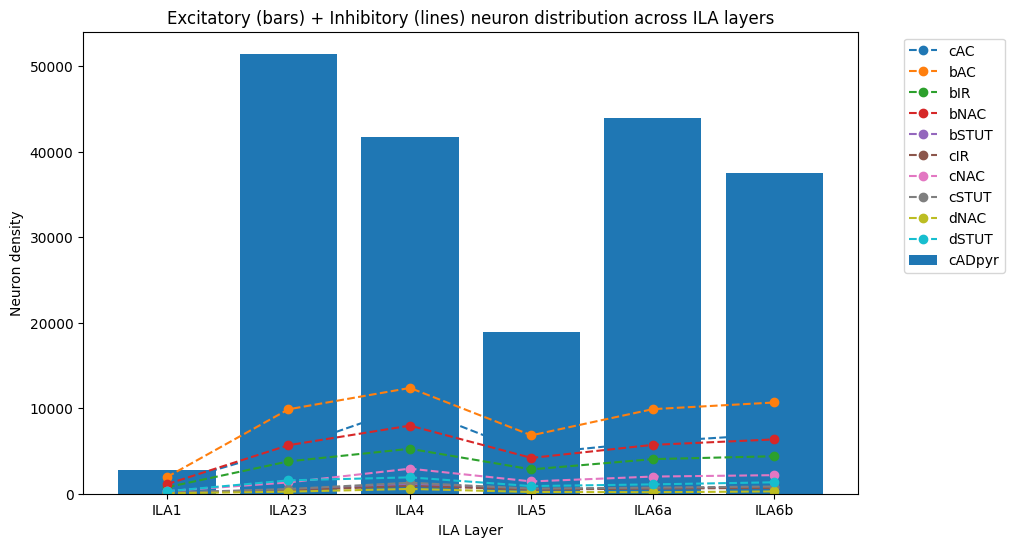

In [19]:
laminar_order = ["ILA1", "ILA23", "ILA4", "ILA5", "ILA6a", "ILA6b"]

plt.figure(figsize=(10,6))

# Plot excitatory stacked bars first
bottoms = [0]*len(laminar_order)
for neuron in excitatory:
    plt.bar(laminar_order, df.loc[neuron], bottom=bottoms, label=neuron)
    bottoms = [sum(x) for x in zip(bottoms, df.loc[neuron])]

# Plot inhibitory neurons as line plots
for neuron in inhibitory:
    plt.plot(laminar_order, df.loc[neuron], marker='o', linestyle='--', label=neuron)

plt.xlabel("ILA Layer")
plt.ylabel("Neuron density")
plt.title("Excitatory (bars) + Inhibitory (lines) neuron distribution across ILA layers")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

In [20]:
# Define the columns and index to keep 
cols_to_keep = ['ILA23', 'AUDv23', 'SSs23', 'VISp23']
neurons_to_keep = ["cAC","cADpyr","cIR","cNAC","cSTUT","dNAC","dSTUT"]

# Filter dataframe
filtered_df = e_data_df.T.loc[neurons_to_keep, cols_to_keep]
filtered_df

,ILA23,AUDv23,SSs23,VISp23
cAC,14999.631058,5299.604489,6390.202513,5318.720260
cADpyr,63389.003020,51438.039378,47497.604139,59262.570826
cIR,1300.356260,387.485135,390.739712,276.831181
cNAC,4192.364405,1320.012549,1419.612480,997.658721
cSTUT,1982.763678,550.865658,650.169600,463.362855
dNAC,1006.726037,240.214764,365.962849,263.589925
dSTUT,2364.242838,1560.587279,1932.460746,2166.708284


Looking for FRP1..

In [23]:
file = PROJECT_ROOT / 'densities_app/scaled_densities_new.pickle'

data = pd.read_pickle(file)
sorted_dict = {k: data[k] for k in sorted(data)}
densities_df = pd.concat({k: v.iloc[:, 0] for k, v in sorted_dict.items()}, axis=1).T
densities_df.shape

(719, 5274)

In [24]:
densities_df.index[densities_df.index.str.contains("FRP")]


Index(['FRP23', 'FRP5', 'FRP6a', 'FRP6b'], dtype='object')

In [25]:
#Next, we load the t-type density file, part of the repo
data = pd.read_pickle(PROJECT_ROOT / 'densities_app/scaled_densities_t_types_as_keys.pickle')
sorted_dict = {k: data[k] for k in sorted(data)}
densities_df = pd.concat({k: v.iloc[:, 0] for k, v in sorted_dict.items()}, axis=1)

In [26]:
densities_df.index[densities_df.index.str.contains("FRP")]

Index(['FRP6a', 'FRP5', 'FRP6b', 'FRP23'], dtype='object')